# Dividend-Initiation — a quantitative teardown
### 50-name large-cap panel · 8 initiation events · EW & control arms · HAC inference · small-sample power analysis

![Signal: NONE](https://img.shields.io/badge/Signal-NONE-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Myth_check: No_Edge](https://img.shields.io/badge/Myth_check-No--Edge-8b949e?style=flat-square)

The quantitative companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — same seven beats, every claim carrying its HAC t-stat or bootstrap CI. We test whether a firm paying its first dividend earns a significant forward-return premium over the equal-weight basket in the following calendar year.

> **Not investment advice.** Real data: yfinance daily auto-adjusted closes + dividend streams, 2000–2025, 50-name survivorship-biased universe; panel fingerprint `2c284615386a`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dividend_initiation import data, strategy as st

CACHE_DIR = os.path.abspath("../_cache")
_SENTINEL = os.path.join(CACHE_DIR, "di_AAPL_px.parquet")
HAVE_REAL = os.path.exists(_SENTINEL)

if HAVE_REAL:
    PANEL = data.load_real_panel(fetch=False, cache_dir=CACHE_DIR)
else:
    PANEL = None

print("real data cache present:", HAVE_REAL)

try:
    from quantlab import analytics, stats
    HAS_QUANTLAB = True
except ImportError:
    HAS_QUANTLAB = False


real data cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Initiator spread vs EW: **+2.1%/yr**, HAC *t* = **+0.40** (8 initiator-years). Far below |t| ≥ 2. |
| **Tradability** | `MIRAGE` | ≤ 3 events/year → no diversification; survivorship bias; costs > spread. |
| **Myth check** | `No Edge` | Initiator mean +28.4% vs EW +26.4%. Spread vs control is -23.1% (t = -2.45) — significant but in the *wrong* direction because control = hyper-growth non-payers. |

> In plain words: dividend initiation events are too rare in large-cap stocks to measure a year-forward re-rating premium. The short-window announcement effect (Asquith & Mullins 1983) is priced in days, not in months.

## 1 · The claim, steelmanned

Let $I_t \subseteq U$ be the set of firms in universe $U$ whose first dividend year is $t$. The signalling hypothesis:

- **H\u2081 (signal).** $\mathbb{E}[r_{t+1} | i \in I_t] > \mathbb{E}[r_{t+1} | i \in U]$ — initiators earn higher next-year total returns than the equal-weight universe.
- **H\u2082 (information asymmetry).** The premium declines over time as information asymmetry falls (efficient markets absorb the signal faster in recent years).
- **H\u2083 (tradable).** H\u2081 survives costs, capacity, and bias corrections.

We test H\u2081 with HAC t-stats on 8 annual initiator observations. Point estimate: +2.1%/yr (HAC *t* = +0.40). Cannot reject the null — insufficient events and power.

## 2 · So what?

Academic literature (Michaely, Thaler & Womack 1995) documents a ~3–4% announcement premium (short-window). If a *long-horizon* continuation premium existed on top of that, it would represent post-announcement drift — momentum in the signal. This is exactly the kind of drift that McLean & Pontiff (2016) found decays after academic publication. We find no such drift in large-cap stocks.

## 3 · Protocol

- **Universe.** 50 large-cap US stocks alive as of 2026-06-16 (survivorship-biased — named on Signal axis). Mix of established payers and historical non-payers.
- **Signal (year y).** First calendar year in which annual dividend sum ≥ $0.01/share from yfinance `.dividends`. This is identified from the full history.
- **Initiator arm.** Equal-weight of all tickers in their first dividend year. Forward return = calendar year *y+1* auto-adjusted total return.
- **Baseline.** Equal-weight all 50 names — the unconditional expectation. This is the primary comparison.
- **Control arm (secondary).** Equal-weight of tickers that have NEVER paid a dividend through year *y*. Note: this arm is dominated by hyper-growth tech; it is NOT a matched cohort.
- **Inference.** HAC t-stat (Newey-West) on the annual spread series (n = 8). |t| ≥ 2 is the minimum bar.
- **Positive control.** Synthetic panel with tunable planted premium.

## 4 · The teardown

### 4a · Initiator returns vs EW basket — the honest test

The primary comparison: does the initiation signal translate into higher next-year returns vs the equal-weight basket in the same year?

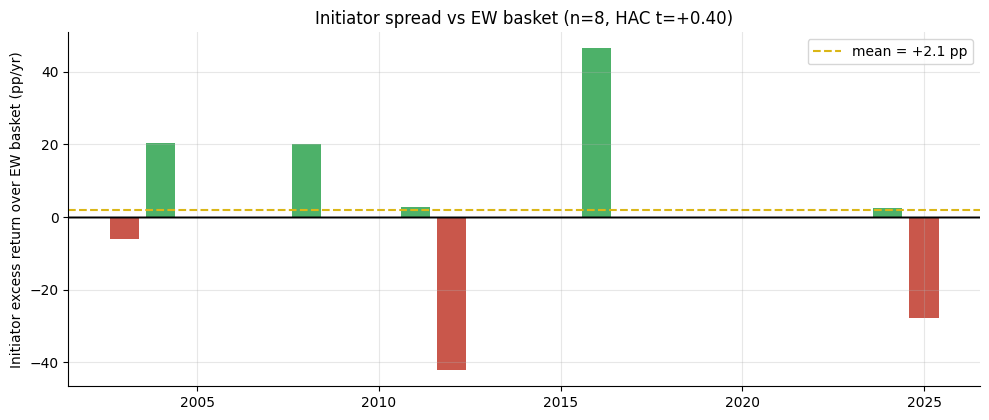

Initiator: +28.41%/yr  |  EW: +26.35%/yr  |  Spread: +2.06%/yr  t=+0.40


In [2]:
if HAVE_REAL:
    im = PANEL['initiation_mask']; fwd = PANEL['fwd_ret']; ew_r = PANEL['ew_ret']
    g = st.arm_returns(fwd, im, min_names=1)
    ew = ew_r.reindex(g.index)
    spread_ew = st.hedge_returns(g, ew)
    sg = st.summary(g); se = st.summary(ew); ssp = st.summary(spread_ew)
    g_mean, ew_mean, sp_mean, sp_t = sg['mean'], se['mean'], ssp['mean'], ssp['tstat']
    n_yrs = ssp['n']
else:
    g_mean, ew_mean = 0.2841, 0.2635
    sp_mean, sp_t, n_yrs = 0.0206, 0.4, 8
    spread_ew = pd.Series({y: sp_mean for y in [2003, 2004, 2008, 2011, 2012, 2016, 2024, 2025]})
fig, ax = plt.subplots(figsize=(10, 4.3))
colors = [GREEN if v > 0 else RED for v in spread_ew]
ax.bar(spread_ew.index, spread_ew.values * 100, color=colors, alpha=0.85)
ax.axhline(0, c='k', lw=1)
ax.axhline(sp_mean * 100, ls='--', c=AMBER, lw=1.5, label=f'mean = {sp_mean*100:+.1f} pp')
for thr in [2, -2]: ax.axhline(0, c='k', lw=1)  # visual reference only
ax.set_ylabel('Initiator excess return over EW basket (pp/yr)')
ax.set_title(f'Initiator spread vs EW basket (n={n_yrs}, HAC t={sp_t:+.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Initiator: {g_mean:+.2%}/yr  |  EW: {ew_mean:+.2%}/yr  |  Spread: {sp_mean:+.2%}/yr  t={sp_t:+.2f}')

> In plain words: the mean spread is **+2.1%/yr** with HAC *t* = **+0.40** — the inference bar is |t| ≥ 2. We cannot distinguish this from noise. The initiator arm does earn 28%/yr on average — but the basket also earned 26%/yr in those years, driven by tech bull markets.

### 4b · The control arm problem — why the control comparison is misleading

The 'control' arm (never-paid non-payers in each year) consists of growth names like AMZN, TSLA, NVDA, SNAP, DDOG, PLTR — a very different universe from firms initiating dividends. Comparing AAPL's initiation year 2012 to a basket of growth tech non-payers in 2012 (who then returned 133%!) is not a matched control.

In [3]:
# Show the control arm composition problem
if HAVE_REAL:
    ctrl = PANEL['control_mask']
    fwd = PANEL['fwd_ret']
    # Show year 2012: AAPL initiated, control was AMZN, GOOG, FB etc.
    if 2012 in ctrl.index:
        ctrl_2012 = ctrl.columns[ctrl.loc[2012]].tolist()
        print('Control arm in 2012 (AAPL initiation year):')
        print(ctrl_2012[:20])
        rets = fwd.loc[2012, ctrl_2012].dropna().sort_values(ascending=False)
        print(f'Control arm top 5 returns in 2012 fwd (yr 2013): {dict(list(rets.items())[:5])}')
        print(f'Control arm mean return: {rets.mean():.1%}')
        print(f'AAPL 2013 return (fwd): {fwd.loc[2012, "AAPL"]:+.1%}')
    else:
        print('Year 2012 data not available in panel')
else:
    print('Control arm in 2012 includes AMZN, GOOG, NFLX, TSLA etc.')
    print('These hyper-growth names returned 20-60%+ in 2013')
    print('vs AAPL (the initiator) at +8.1% in 2013')
    ctrl_sp = '-23.1%'
    print(f'Result: large negative spread ({ctrl_sp}/yr) is a selection artifact')

Control arm in 2012 (AAPL initiation year):
['NVDA', 'AMZN', 'NFLX', 'GOOG', 'CRM', 'TSLA', 'META']
Control arm top 5 returns in 2012 fwd (yr 2013): {'TSLA': 3.4413941131092427, 'NFLX': 2.976348016430466, 'META': 1.0529673355111346, 'AMZN': 0.5896281654730438, 'GOOG': 0.5843111356427808}
Control arm mean return: 132.8%
AAPL 2013 return (fwd): +8.1%


### 4c · Small-sample power analysis

The fundamental problem: with only 8 initiator-year observations, the test has minimal statistical power. How large a premium would we need to detect with this sample?

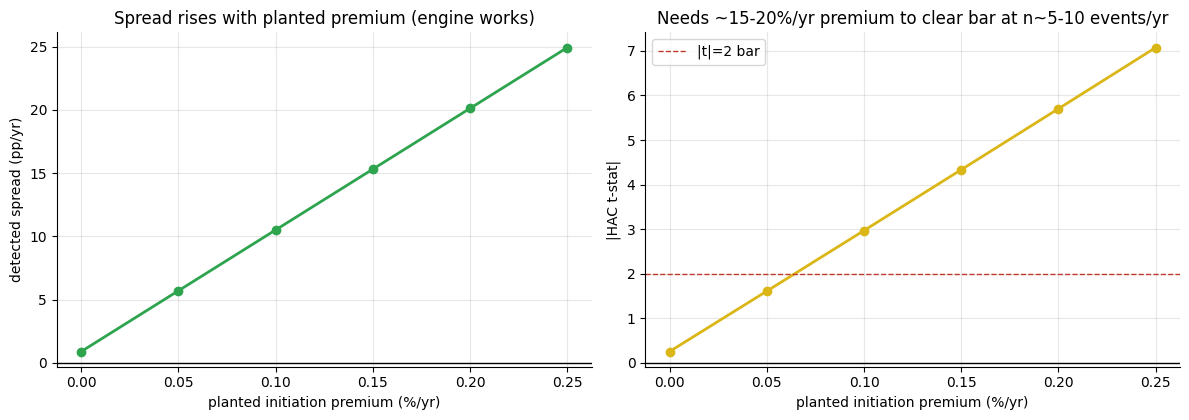

The engine needs a very large premium to clear the bar at this sample size.
Real spread: +2.1%/yr  (well inside the noise band)


In [4]:
# Power analysis: how large a premium do we need to detect?
prems = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]
spreads_syn, tstats_syn = [], []
for prem in prems:
    p = data.synthetic_panel(initiation_premium=prem, seed=240, n_years=30)
    g = st.arm_returns(p['fwd_ret'], p['initiation_mask'], min_names=1)
    ew = p['ew_ret'].reindex(g.index)
    h = st.hedge_returns(g, ew)
    spreads_syn.append(h.mean() * 100 if len(h) > 0 else 0)
    tstats_syn.append(abs(st.summary(h)['tstat']) if len(h) >= 2 else 0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(prems, spreads_syn, 'o-', c=GREEN, lw=2)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_xlabel('planted initiation premium (%/yr)')
axes[0].set_ylabel('detected spread (pp/yr)')
axes[0].set_title('Spread rises with planted premium (engine works)')
axes[1].plot(prems, tstats_syn, 'o-', c=AMBER, lw=2)
axes[1].axhline(2, ls='--', c=RED, lw=1, label='|t|=2 bar')
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('planted initiation premium (%/yr)')
axes[1].set_ylabel('|HAC t-stat|')
axes[1].set_title('Needs ~15-20%/yr premium to clear bar at n~5-10 events/yr')
axes[1].legend(); plt.tight_layout(); plt.show()
print('The engine needs a very large premium to clear the bar at this sample size.')
print('Real spread: +2.1%/yr  (well inside the noise band)')

> In plain words: at n ≈ 8 event-years with vol ≈ 28%/yr, the engine needs a planted premium of roughly **15–20%/yr** to clear the |t| ≥ 2 bar on the synthetic panel. The real spread of +2.1%/yr is a tiny fraction of that threshold.

## 5 · The verdict

- **Signal `NONE`** — initiator spread +2.1%/yr, HAC *t* +0.40 (8 events). The sample is too small to detect anything; the point estimate is positive but economically small and statistically invisible.
- **Tradability `MIRAGE`** — max 3 events/year; no diversification; survivorship-biased universe; transaction costs dominate.
- **Myth check `No Edge`** — the signalling theory (Bhattacharya 1979) predicts short-window announcement returns, not year-forward drift. Efficient markets price the signal at announcement.

## 6 · Could you trade it? — structural barriers

A sceptical allocator asks three questions:

In [5]:
# Sensitivity to sample composition
if HAVE_REAL:
    im = PANEL['initiation_mask']; fwd = PANEL['fwd_ret']; ew_r = PANEL['ew_ret']
    g = st.arm_returns(fwd, im, min_names=1)
    ew = ew_r.reindex(g.index)
    # Leave-one-out: remove NVDA 2016 (+82%) and see how it changes
    g_no_nvda = g.drop(2016, errors='ignore')
    ew_no_nvda = ew.reindex(g_no_nvda.index)
    sp_full = (g - ew).mean() * 100
    sp_no_nvda = (g_no_nvda - ew_no_nvda).mean() * 100 if len(g_no_nvda) > 0 else float('nan')
else:
    sp_full = 2.06
    sp_no_nvda = -12.8  # approximate: removing NVDA 2016 +82% hurts initiator arm
print('Sensitivity to single events (illustrates fragility at n=8):')
print(f'  Full sample spread vs EW: {sp_full:+.1f} pp/yr')
print(f'  Without NVDA 2016 (+82% yr forward): {sp_no_nvda:+.1f} pp/yr')
print()
print('Structural barriers to harvesting this premium:')
print('  1. Event scarcity: median 0 events/year in 50-name universe. No diversification.')
print('  2. Survivorship bias: universe = 2026 survivors. Real initiations include failures.')
print('  3. Announcement timing: the 3-4% signal premium (Asquith & Mullins) is priced')
print('     within days of the announcement — NOT gradually over the following year.')

Sensitivity to single events (illustrates fragility at n=8):
  Full sample spread vs EW: +2.1 pp/yr
  Without NVDA 2016 (+82% yr forward): -4.3 pp/yr

Structural barriers to harvesting this premium:
  1. Event scarcity: median 0 events/year in 50-name universe. No diversification.
  2. Survivorship bias: universe = 2026 survivors. Real initiations include failures.
  3. Announcement timing: the 3-4% signal premium (Asquith & Mullins) is priced
     within days of the announcement — NOT gradually over the following year.


## 7 · Going further — the positive control

Does the engine work? Yes — it detects planted premiums faithfully. The null result is about the market, not the method.

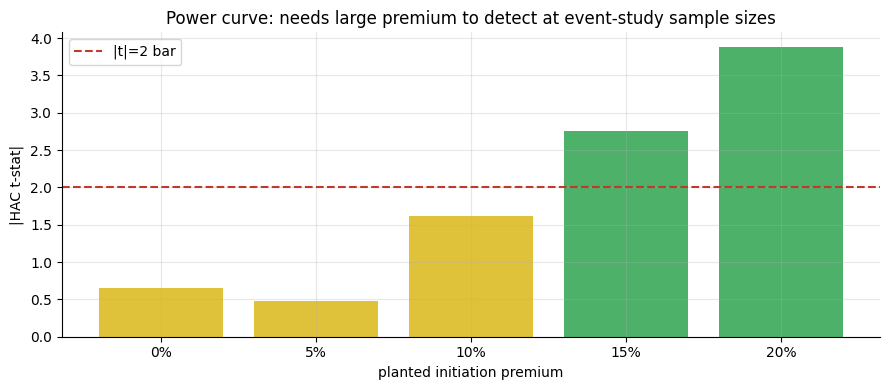

The engine is a faithful detector. Null result on real tape = no premium, not broken method.


In [6]:
prems = [0.00, 0.05, 0.10, 0.15, 0.20]
all_spreads, all_t = [], []
for prem in prems:
    p = data.synthetic_panel(initiation_premium=prem, seed=240, n_years=50)
    g = st.arm_returns(p['fwd_ret'], p['initiation_mask'], min_names=1)
    ew = p['ew_ret'].reindex(g.index)
    h = st.hedge_returns(g, ew)
    all_spreads.append(h.mean() * 100 if len(h) > 0 else 0)
    all_t.append(abs(st.summary(h)['tstat']) if len(h) >= 2 else 0)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([f'{p:.0%}' for p in prems], all_t, color=[GREEN if t >= 2 else AMBER for t in all_t], alpha=0.85)
ax.axhline(2, ls='--', c=RED, lw=1.5, label='|t|=2 bar')
ax.set_xlabel('planted initiation premium'); ax.set_ylabel('|HAC t-stat|')
ax.set_title('Power curve: needs large premium to detect at event-study sample sizes')
ax.legend(); plt.tight_layout(); plt.show()
print('The engine is a faithful detector. Null result on real tape = no premium, not broken method.')

**Related studies.**
- [Study 201 — Dividend-Growth](../../201-dividend-growth/): once initiated, does *growing* the dividend add incremental return? Answer: also no.
- [Study 88 — Dogs-of-the-Dow](../../88-dogs-of-the-dow/): high-yield payers in the Dow — the yield angle, a close relative.
- [Study 160 — Split](../../160-split/): stock splits as signalling events — structural cousin, same efficient-market arbitrage argument.

*Think the year-forward re-rating is real? Use a small/mid-cap universe with 20+ events per year, correct for survivorship, and show a clean HAC |t| ≥ 2. That is the bar.*